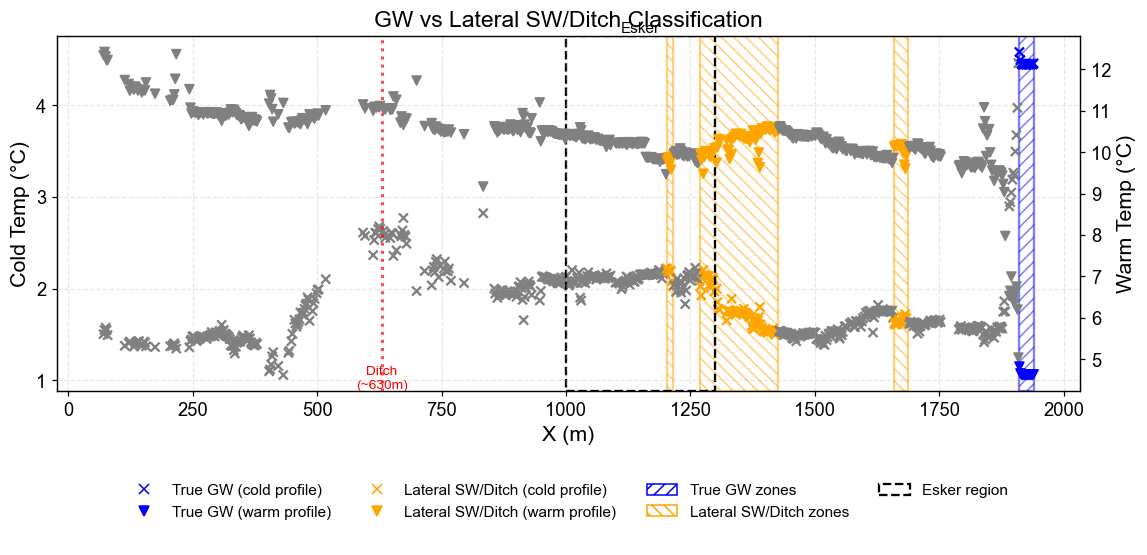

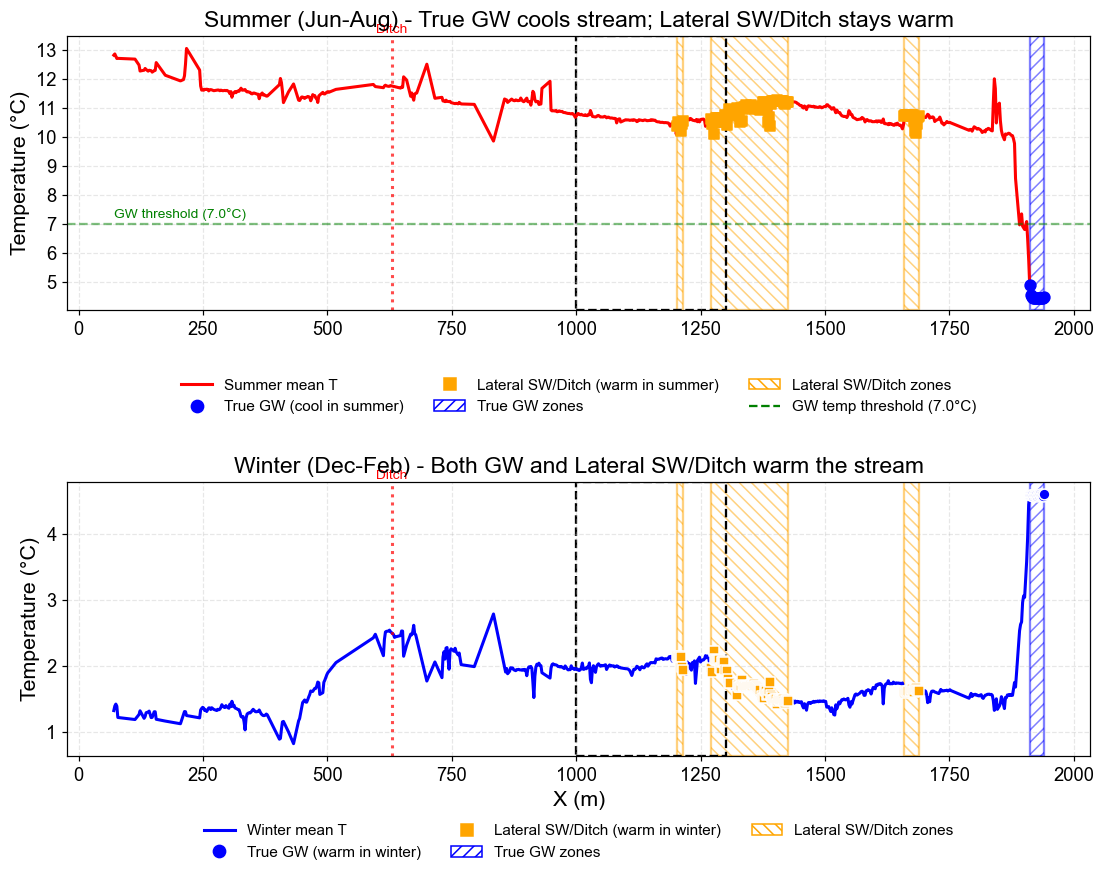

CLASSIFICATION SUMMARY

TRUE GROUNDWATER INFLOWS: 1 segments
  (Cool in summer, warm in winter - stable ~4-5°C signature)
    Segment 1: 1911.2m - 1939.6m (length: 28.4m)

LATERAL SURFACE WATER / DITCH INFLOWS: 3 segments
  (Warm in summer too - surface water, not groundwater)
    Segment 1: 1203.0m - 1215.2m (length: 12.2m)
    Segment 2: 1270.0m - 1426.2m (length: 156.2m)
    Segment 3: 1659.6m - 1688.0m (length: 28.4m)

Ditch at ~630m captured as Lateral SW: False


In [5]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore", message="All-NaN slice encountered")
warnings.filterwarnings("ignore", message=".*tight_layout.*")

# Matplotlib style 

mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update({
    "font.family": "Arial",
    "font.style": "normal",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 110,
    "savefig.dpi": 300,
})


# Load DTS dataset

file = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\Bachup\DTS\Dataset - All\pallas_dts_data_f_6.nc"
data = xr.open_dataset(file)


# Define seasonal masks (summer: Jun-Aug, winter: Dec-Feb)

dts_time = data["time"]
summer_mask = (dts_time.dt.month >= 6) & (dts_time.dt.month <= 8)
winter_mask = (dts_time.dt.month == 12) | (dts_time.dt.month <= 2)

# Night-time mask
night_mask = ((dts_time.dt.hour >= 22) | (dts_time.dt.hour < 6))

# Combined seasonal + night masks
summer_night_mask = summer_mask & night_mask
winter_night_mask = winter_mask & night_mask

# Select data for each season (for visualization)
data_summer_night = data.sel(time=summer_night_mask)
data_winter_night = data.sel(time=winter_night_mask)

# Compute seasonal mean temperature profiles (for visualization)
summer_mean = data_summer_night["T"].mean(dim="time").dropna(dim="x")
winter_mean = data_winter_night["T"].mean(dim="time").dropna(dim="x")


# ============================================================
# GW DETECTION: Using CROSS-SEASONAL reverse slope method
# (Same as original - comparing winter vs summer gradients)
# ============================================================

# Use ALL nighttime data for the original GW detection method
data_night = data.sel(time=night_mask)

# Cold profile (25th percentile) = dominated by winter temps
# Warm profile (75th percentile) = dominated by summer temps
min_data = data_night["T"].quantile(0.25, dim="time").dropna(dim="x")
max_data = data_night["T"].quantile(0.75, dim="time").dropna(dim="x")

# Align x coordinates
x_common = np.intersect1d(min_data["x"].values, max_data["x"].values)
x_common = np.intersect1d(x_common, summer_mean["x"].values)
x_common = np.intersect1d(x_common, winter_mean["x"].values)

min_data = min_data.sel(x=x_common)
max_data = max_data.sel(x=x_common)
summer_mean = summer_mean.sel(x=x_common)
winter_mean = winter_mean.sel(x=x_common)
x = min_data["x"]


# Rolling slope function 

def rolling_slope(T, window):
    T_roll = T.rolling(x=window, center=True).construct("window")
    x_win = T["x"].rolling(x=window, center=True).construct("window")
    x_cent = x_win - T["x"].values[:, None]
    return (
        (x_cent * T_roll).mean("window")
        - x_cent.mean("window") * T_roll.mean("window")
    ) / (
        (x_cent**2).mean("window")
        - (x_cent.mean("window"))**2
    )


# Compute longitudinal temperature gradients (CROSS-SEASONAL)

window = 40
min_deriv = rolling_slope(min_data, window)  # Cold (winter-like) gradient
max_deriv = rolling_slope(max_data, window)  # Warm (summer-like) gradient


# Groundwater inflow classification (reverse slopes between cold and warm profiles)

gw_thresh = 0.0015

# GW detection: cold profile negative slope AND warm profile positive slope
gw_class = xr.where((min_deriv < -gw_thresh) & (max_deriv > gw_thresh), 1, np.nan)

# Spatial coherence filter
gw_class = xr.where(
    gw_class.rolling(x=10, center=True, min_periods=1).sum() > 5,
    1,
    np.nan
)

# Spring detection (stable temperature ~4-5°C indicating strong GW influence)
spring_mask = (
    (min_data > 4) & (min_data < 5) &
    (max_data > 4) & (max_data < 5)
)
gw_class = xr.where(spring_mask, 1, gw_class)


# ============================================================
# DISTINGUISH TRUE GW vs LATERAL SW/DITCH INFLOWS
# ============================================================
# Key insight: True GW has stable temperature ~4-5°C year-round
# - In summer: GW COOLS the stream → summer temps should be relatively cool
# - Ditch/SW: Brings warm surface water in summer → summer temps are warm
#
# Filter: If summer temperature is too warm (> threshold), it's likely SW/ditch, not GW

# Calculate seasonal temperature difference
summer_winter_diff = summer_mean - winter_mean

# Expected GW temperature range
gw_temp_summer_max = 7.0  # True GW locations should have summer temps below this
gw_temp_range_min = 3.5   # GW typically 4-5°C, allow some margin
gw_temp_range_max = 6.5

# Identify TRUE GW: reverse slope + summer temps consistent with GW cooling effect
# (summer temps should be cooler, not warmer than background)
true_gw_mask = (
    (gw_class == 1) & 
    (summer_mean < gw_temp_summer_max)  # Summer temps not too warm
)

# Identify LATERAL SW/DITCH: has reverse slope pattern but summer temps are too warm
# This indicates surface water influence, not groundwater
lateral_sw_mask = (
    (gw_class == 1) & 
    (summer_mean >= gw_temp_summer_max)  # Summer temps too warm for GW
)

# Alternative detection: warm anomaly in summer suggests surface water
# Calculate local summer temperature anomaly
summer_smooth = summer_mean.rolling(x=80, center=True).mean()
summer_anom = summer_mean - summer_smooth

# Lateral SW: locations with positive summer anomaly (warmer than local trend)
# combined with the reverse slope pattern
lateral_sw_mask = lateral_sw_mask | (
    (gw_class == 1) & 
    (summer_anom > 0.3)  # Warmer than local trend in summer
)

# Final masks
gw_mask = np.where(true_gw_mask.fillna(False).values, 1, 0)
lateral_sw_mask_vals = np.where(lateral_sw_mask.fillna(False).values, 1, 0)

# Combined original mask (for reference)
combined_mask = gw_class.fillna(0).values


# Extract continuous spatial segments

def extract_segments(x_vals, mask):
    segments = []
    in_segment = False
    for i in range(len(x_vals)):
        if mask[i] == 1 and not in_segment:
            start = x_vals[i]
            in_segment = True
        if in_segment and (mask[i] == 0 or i == len(x_vals) - 1):
            end = x_vals[i - 1] if mask[i] == 0 else x_vals[i]
            segments.append((start, end))
            in_segment = False
    return segments

gw_segments = extract_segments(x.values, gw_mask)
lateral_sw_segments = extract_segments(x.values, lateral_sw_mask_vals)


# Esker reference region

esker_start = 1000
esker_end   = 1300


# ============================================================
# FIGURE – GW vs Lateral SW/Ditch Classification
# (Shows both true GW and lateral SW inflows with different colors)
# ============================================================

fig1 = plt.figure(figsize=(12, 6))
gs1 = mpl.gridspec.GridSpec(2, 1, height_ratios=[4, 1.2], hspace=0.2)

ax_w = fig1.add_subplot(gs1[0])
ax_s = ax_w.twinx()
ax_leg1 = fig1.add_subplot(gs1[1])
ax_leg1.axis("off")

# Plot GW zones (blue hatching)
for xs, xe in gw_segments:
    ax_w.axvspan(xs, xe, facecolor="none", edgecolor="blue", hatch="///", alpha=0.5, linewidth=1.5)

# Plot Lateral SW/Ditch zones (orange hatching)
for xs, xe in lateral_sw_segments:
    ax_w.axvspan(xs, xe, facecolor="none", edgecolor="orange", hatch="\\\\\\", alpha=0.5, linewidth=1.5)

# Color points by classification
point_colors = np.where(gw_mask == 1, "blue", 
                        np.where(lateral_sw_mask_vals == 1, "orange", "grey"))

ax_w.scatter(x, min_data, c=point_colors, marker="x", s=35)
ax_s.scatter(x, max_data, c=point_colors, marker="v", s=35)

# Set y-tick intervals to 1 for both axes
ax_w.yaxis.set_major_locator(plt.MultipleLocator(1))
ax_s.yaxis.set_major_locator(plt.MultipleLocator(1))

ax_w.set_ylabel("Cold Temp (°C)")
ax_s.set_ylabel("Warm Temp (°C)")
ax_w.set_xlabel("X (m)")
ax_w.set_title("GW vs Lateral SW/Ditch Classification")
ax_w.grid(True, linestyle="--", alpha=0.3)

# Esker region
ax_w.axvspan(esker_start, esker_end, facecolor="none", edgecolor="black", linestyle="--", linewidth=1.5)
ax_w.text(
    0.5 * (esker_start + esker_end),
    ax_w.get_ylim()[1],
    "Esker",
    ha="center",
    va="bottom",
    fontsize=10,
)

# Mark the ditch location (~630m)
ditch_x = 630
ax_w.axvline(x=ditch_x, color="red", linestyle=":", linewidth=2, alpha=0.7)
ax_w.text(ditch_x, ax_w.get_ylim()[0], "Ditch\n(~630m)", 
          ha="center", va="bottom", fontsize=9, color="red")

ax_leg1.legend(
    [
        plt.Line2D([], [], color="blue", marker="x", linestyle=""),
        plt.Line2D([], [], color="blue", marker="v", linestyle=""),
        plt.Line2D([], [], color="orange", marker="x", linestyle=""),
        plt.Line2D([], [], color="orange", marker="v", linestyle=""),
        mpl.patches.Patch(facecolor="none", edgecolor="blue", hatch="///"),
        mpl.patches.Patch(facecolor="none", edgecolor="orange", hatch="\\\\\\"),
        mpl.patches.Patch(facecolor="none", edgecolor="black", linestyle="--", linewidth=1.5),
    ],
    [
        "True GW (cold profile)",
        "True GW (warm profile)",
        "Lateral SW/Ditch (cold profile)",
        "Lateral SW/Ditch (warm profile)",
        "True GW zones",
        "Lateral SW/Ditch zones",
        "Esker region",
    ],
    loc="center",
    bbox_to_anchor=(0.5, 0.4),
    ncol=4,
    frameon=False,
    fontsize=10
)

plt.tight_layout()
plt.show()


# ============================================================
# FIGURE 2 – Seasonal Temperature Profiles with GW & Lateral SW zones
# (Summer on top, Winter below - showing the key difference)
# ============================================================

fig2 = plt.figure(figsize=(12, 10))
gs2 = mpl.gridspec.GridSpec(4, 1, height_ratios=[4, 1.2, 4, 1.2], hspace=0.25)

# ========== SUMMER PLOT (top) ==========
ax_summer = fig2.add_subplot(gs2[0])
ax_leg_summer = fig2.add_subplot(gs2[1])
ax_leg_summer.axis("off")

# GW zones (blue)
for xs, xe in gw_segments:
    ax_summer.axvspan(xs, xe, facecolor="none", edgecolor="blue", hatch="///", alpha=0.5, linewidth=1.5)

# Lateral SW/Ditch zones (orange)
for xs, xe in lateral_sw_segments:
    ax_summer.axvspan(xs, xe, facecolor="none", edgecolor="orange", hatch="\\\\\\", alpha=0.5, linewidth=1.5)

# Summer mean temperature profile
ax_summer.plot(x, summer_mean, color="red", lw=2.0, label="Summer mean T")
ax_summer.scatter(x[gw_mask == 1], summer_mean.values[gw_mask == 1], 
                  color="blue", s=50, zorder=5, marker="o", label="True GW")
ax_summer.scatter(x[lateral_sw_mask_vals == 1], summer_mean.values[lateral_sw_mask_vals == 1], 
                  color="orange", s=50, zorder=5, marker="s", label="Lateral SW/Ditch")

# Add horizontal line for GW temperature threshold
ax_summer.axhline(y=gw_temp_summer_max, color="green", linestyle="--", alpha=0.5, linewidth=1.5)
ax_summer.text(x.values[0], gw_temp_summer_max + 0.1, f"GW threshold ({gw_temp_summer_max}°C)", 
               fontsize=9, color="green", va="bottom")

ax_summer.yaxis.set_major_locator(plt.MultipleLocator(1))
ax_summer.set_ylabel("Temperature (°C)")
ax_summer.set_title("Summer (Jun-Aug) - True GW cools stream; Lateral SW/Ditch stays warm")
ax_summer.grid(True, linestyle="--", alpha=0.3)

# Esker region
ax_summer.axvspan(esker_start, esker_end, facecolor="none", edgecolor="black", linestyle="--", linewidth=1.5)

# Mark ditch location
ax_summer.axvline(x=ditch_x, color="red", linestyle=":", linewidth=2, alpha=0.7)
ax_summer.text(ditch_x, ax_summer.get_ylim()[1], "Ditch", ha="center", va="bottom", fontsize=9, color="red")

# Legend for summer
ax_leg_summer.legend(
    [
        plt.Line2D([], [], color="red", linewidth=2.0),
        plt.Line2D([], [], color="blue", marker="o", linestyle="", markersize=8),
        plt.Line2D([], [], color="orange", marker="s", linestyle="", markersize=8),
        mpl.patches.Patch(facecolor="none", edgecolor="blue", hatch="///"),
        mpl.patches.Patch(facecolor="none", edgecolor="orange", hatch="\\\\\\"),
        plt.Line2D([], [], color="green", linestyle="--", linewidth=1.5),
    ],
    [
        "Summer mean T",
        "True GW (cool in summer)",
        "Lateral SW/Ditch (warm in summer)",
        "True GW zones",
        "Lateral SW/Ditch zones",
        f"GW temp threshold ({gw_temp_summer_max}°C)",
    ],
    loc="center",
    bbox_to_anchor=(0.5, 0.5),
    ncol=3,
    frameon=False,
    fontsize=10
)


# ========== WINTER PLOT (bottom) ==========
ax_winter = fig2.add_subplot(gs2[2], sharex=ax_summer)
ax_leg_winter = fig2.add_subplot(gs2[3])
ax_leg_winter.axis("off")

# GW zones (blue)
for xs, xe in gw_segments:
    ax_winter.axvspan(xs, xe, facecolor="none", edgecolor="blue", hatch="///", alpha=0.5, linewidth=1.5)

# Lateral SW/Ditch zones (orange)
for xs, xe in lateral_sw_segments:
    ax_winter.axvspan(xs, xe, facecolor="none", edgecolor="orange", hatch="\\\\\\", alpha=0.5, linewidth=1.5)

# Winter mean temperature profile
ax_winter.plot(x, winter_mean, color="blue", lw=2.0, label="Winter mean T")
ax_winter.scatter(x[gw_mask == 1], winter_mean.values[gw_mask == 1], 
                  color="blue", s=50, zorder=5, marker="o", edgecolor="white", linewidth=1)
ax_winter.scatter(x[lateral_sw_mask_vals == 1], winter_mean.values[lateral_sw_mask_vals == 1], 
                  color="orange", s=50, zorder=5, marker="s", edgecolor="white", linewidth=1)

ax_winter.yaxis.set_major_locator(plt.MultipleLocator(1))
ax_winter.set_ylabel("Temperature (°C)")
ax_winter.set_xlabel("X (m)")
ax_winter.set_title("Winter (Dec-Feb) - Both GW and Lateral SW/Ditch warm the stream")
ax_winter.grid(True, linestyle="--", alpha=0.3)

# Esker region
ax_winter.axvspan(esker_start, esker_end, facecolor="none", edgecolor="black", linestyle="--", linewidth=1.5)

# Mark ditch location
ax_winter.axvline(x=ditch_x, color="red", linestyle=":", linewidth=2, alpha=0.7)
ax_winter.text(ditch_x, ax_winter.get_ylim()[1], "Ditch", ha="center", va="bottom", fontsize=9, color="red")

# Legend for winter
ax_leg_winter.legend(
    [
        plt.Line2D([], [], color="blue", linewidth=2.0),
        plt.Line2D([], [], color="blue", marker="o", linestyle="", markersize=8),
        plt.Line2D([], [], color="orange", marker="s", linestyle="", markersize=8),
        mpl.patches.Patch(facecolor="none", edgecolor="blue", hatch="///"),
        mpl.patches.Patch(facecolor="none", edgecolor="orange", hatch="\\\\\\"),
    ],
    [
        "Winter mean T",
        "True GW (warm in winter)",
        "Lateral SW/Ditch (warm in winter)",
        "True GW zones",
        "Lateral SW/Ditch zones",
    ],
    loc="center",
    bbox_to_anchor=(0.5, 0.5),
    ncol=3,
    frameon=False,
    fontsize=10
)

plt.tight_layout()
plt.show()


# ============================================================
# SUMMARY
# ============================================================

print("=" * 60)
print("CLASSIFICATION SUMMARY")
print("=" * 60)

print(f"\nTRUE GROUNDWATER INFLOWS: {len(gw_segments)} segments")
print("  (Cool in summer, warm in winter - stable ~4-5°C signature)")
for i, (xs, xe) in enumerate(gw_segments):
    print(f"    Segment {i+1}: {xs:.1f}m - {xe:.1f}m (length: {xe-xs:.1f}m)")

print(f"\nLATERAL SURFACE WATER / DITCH INFLOWS: {len(lateral_sw_segments)} segments")
print("  (Warm in summer too - surface water, not groundwater)")
for i, (xs, xe) in enumerate(lateral_sw_segments):
    print(f"    Segment {i+1}: {xs:.1f}m - {xe:.1f}m (length: {xe-xs:.1f}m)")

# Check if the ditch at 630m is captured
ditch_captured = any((xs <= ditch_x <= xe) for xs, xe in lateral_sw_segments)
print(f"\nDitch at ~630m captured as Lateral SW: {ditch_captured}")